Episode 1/50
Episode 2/50
Episode 3/50
Episode 4/50
Episode 5/50
Episode 6/50
Episode 7/50
Episode 8/50
Episode 9/50
Episode 10/50
Episode 11/50
Episode 12/50
Episode 13/50
Episode 14/50
Episode 15/50
Episode 16/50
Episode 17/50
Episode 18/50
Episode 19/50
Episode 20/50
Episode 21/50
Episode 22/50
Episode 23/50
Episode 24/50
Episode 25/50
Episode 26/50
Episode 27/50
Episode 28/50
Episode 29/50
Episode 30/50
Episode 31/50
Episode 32/50
Episode 33/50
Episode 34/50
Episode 35/50
Episode 36/50
Episode 37/50
Episode 38/50
Episode 39/50
Episode 40/50
Episode 41/50
Episode 42/50
Episode 43/50
Episode 44/50
Episode 45/50
Episode 46/50
Episode 47/50
Episode 48/50
Episode 49/50
Episode 50/50


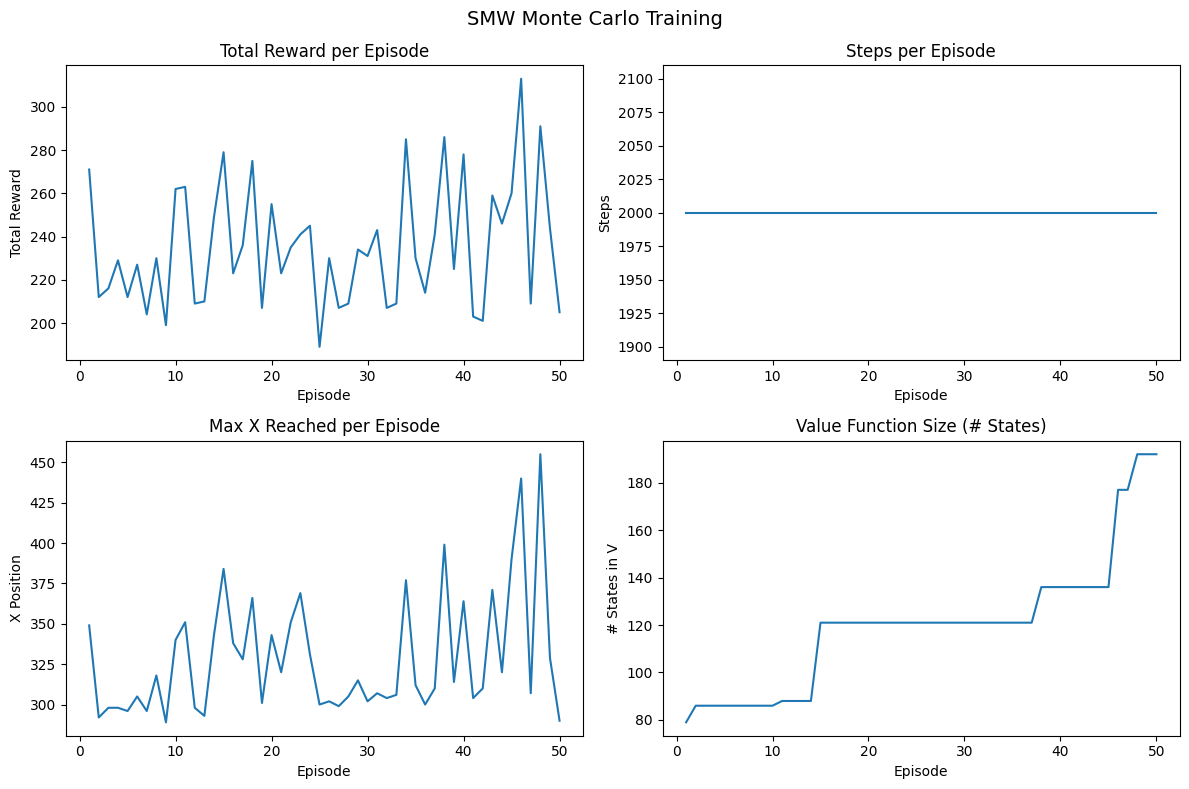

In [4]:
import stable_retro
import matplotlib.pyplot as plt
import numpy as np

env = stable_retro.make(game='SuperMarioWorld-Snes-v0', render_mode=None)

def generate_episode(env):
    state, info = env.reset()
    done = False
    episode_data = []
    prev_x = info.get('x', 0)
    start_x = None
    max_x = 0
    max_steps = 2000

    while not done and len(episode_data) < max_steps:
        action = env.action_space.sample()
        next_state, reward, done, trunc, info = env.step(action)

        curr_x = info.get('screen', 0) * 256 + info.get('x', 0)
        delta_x = curr_x - prev_x
        reward = 1 if 0 < delta_x < 200 else 0
        prev_x = curr_x
        max_x = max(max_x, curr_x)

        if start_x is None:
            start_x = curr_x
        # ADD IT HERE
        # print(f"curr_x: {curr_x}, start_x: {start_x}, delta: {curr_x - start_x if start_x else 'N/A'}, steps: {len(episode_data)}")
        # print(f"raw info: {info}")

        # if curr_x - start_x >= 128:
        #     done = True
        state_key = (info.get('screen', 0), info.get('x', 0))
        episode_data.append((state_key, action, reward, done))
        state = next_state
        if done or trunc:
            break

    return episode_data, max_x

V = {}
returns_sum = {}
returns_count = {}

num_eps = 50

# tracking
total_rewards = []
steps_per_ep = []
max_x_per_ep = []
v_size_per_ep = []

try:
    for ep_num in range(num_eps):
        print(f"Episode {ep_num + 1}/{num_eps}", flush=True)
        episode, max_x = generate_episode(env)

        states  = [step[0] for step in episode]
        rewards = [step[2] for step in episode]
        G = 0

        visited = set()
        for t in reversed(range(len(episode))):
            state = states[t]
            if state not in visited:
                visited.add(state)
                if state not in returns_sum:
                    returns_sum[state] = 0
                    returns_count[state] = 0
                returns_sum[state] += G
                returns_count[state] += 1
                V[state] = returns_sum[state] / returns_count[state]
            G = G + rewards[t]

        total_rewards.append(sum(rewards))
        steps_per_ep.append(len(episode))
        max_x_per_ep.append(max_x)
        v_size_per_ep.append(len(V))
except KeyboardInterrupt:
    print("Training interrupted!")
finally:
    env.close()

# plotting
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('SMW Monte Carlo Training', fontsize=14)

eps = range(1, num_eps + 1)

axes[0, 0].plot(eps, total_rewards)
axes[0, 0].set_title('Total Reward per Episode')
axes[0, 0].set_xlabel('Episode')
axes[0, 0].set_ylabel('Total Reward')

axes[0, 1].plot(eps, steps_per_ep)
axes[0, 1].set_title('Steps per Episode')
axes[0, 1].set_xlabel('Episode')
axes[0, 1].set_ylabel('Steps')

axes[1, 0].plot(eps, max_x_per_ep)
axes[1, 0].set_title('Max X Reached per Episode')
axes[1, 0].set_xlabel('Episode')
axes[1, 0].set_ylabel('X Position')

axes[1, 1].plot(eps, v_size_per_ep)
axes[1, 1].set_title('Value Function Size (# States)')
axes[1, 1].set_xlabel('Episode')
axes[1, 1].set_ylabel('# States in V')

plt.tight_layout()
plt.savefig('mc_results.png')
plt.show()

In [28]:
# test a bunch of addresses around where x should be
import stable_retro

env = stable_retro.make(game='SuperMarioWorld-Snes-v0', render_mode='human')
env.reset()

for _ in range(100):
    action = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  # hold right
    env.step(action)

ram = env.get_ram()
# print addresses in the range we care about
for addr in [0x00D1, 0x00D3, 0x0086, 0x00D4, 0x00B6, 0x00B8]:
    print(f"0x{addr:04X}: {ram[addr]}")
    print(0x7E0000 + 0x00D1)  # x
    print(0x7E0000 + 0x00D4)  # screen  

env.close()

0x00D1: 129
8257745
8257748
0x00D3: 96
8257745
8257748
0x0086: 0
8257745
8257748
0x00D4: 1
8257745
8257748
0x00B6: 0
8257745
8257748
0x00B8: 0
8257745
8257748
